# 诗歌文本分类与统计判别全过程可视化
本 Notebook 将展示如何利用 TF-IDF 特征工程和多项式朴素贝叶斯（Multinomial Naive Bayes）模型，对短文本（诗句）进行作者归属和位置预测的统计判别过程。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体以支持图表显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## 1. 准备并观测原始数据
我们将收集到的李白与杜甫的诗句转化为结构化的 DataFrame，并为每句诗打上“作者”和“相对位置”的标签。

In [2]:
data = {
    '杜甫': [
        "两个黄鹂鸣翠柳", "一行白鹭上青天", "窗含西岭千秋雪", "门泊东吴万里船", # 绝句
        "国破山河在", "城春草木深", "感时花溅泪", "恨别鸟惊心", # 春望
        "好雨知时节", "当春乃发生", "随风潜入夜", "润物细无声", # 春夜喜雨
        "昔闻洞庭水", "今上岳阳楼", "吴楚东南坼", "乾坤日夜浮", # 登岳阳楼
        "细草微风岸", "危樯独夜舟", "星垂平野阔", "月涌大江流", # 旅夜书怀
        "功盖三分国", "名成八阵图", "江流石不转", "遗恨失吞吴"  # 八阵图
    ],
    '李白': [
        "床前明月光", "疑是地上霜", "举头望明月", "低头思故乡", # 静夜思
        "危楼高百尺", "手可摘星辰", "不敢高声语", "恐惊天上人", # 夜宿山寺
        "众鸟高飞尽", "孤云独去闲", "相看两不厌", "只有敬亭山", # 独坐敬亭山
        "耶溪采莲女", "见客棹歌回", "笑畏郎猜测", "娇羞不肯来", # 越女词
        "天下伤心处", "劳劳送客亭", "春风知别苦", "不遣柳条青", # 劳劳亭
        "秋浦长似秋", "萧条使人愁", "客愁不可度", "行上东大楼"  # 秋浦歌
    ]
}

rows = []
for author, lines in data.items():
    for i, line in enumerate(lines):
        position = (i % 4) + 1 
        rows.append({'text': line, 'author': author, 'position': position})

df = pd.DataFrame(rows)
print("数据集总规模:", df.shape)
display(df.sample(5)) # 随机展示 5 条数据样本

数据集总规模: (48, 3)


,text,author,position
3,门泊东吴万里船,杜甫,4
32,众鸟高飞尽,李白,1
15,乾坤日夜浮,杜甫,4
38,笑畏郎猜测,李白,3
33,孤云独去闲,李白,2


## 2. 特征工程：文本的数学化表示
计算机无法直接理解中文。我们使用 `TfidfVectorizer`，并在字级别（char）设定 `ngram_range=(1,2)`，这意味着模型不仅会学习单个字，还会学习相邻两个字的组合（双字词）。

通过训练集，模型共学习到了 385 个不同的特征维度。

目标测试句: '白水绕东城'
该句子激活的特征及其 TF-IDF 权重:
 - '东': 0.4342
 - '城': 0.5201
 - '水': 0.5201
 - '白': 0.5201


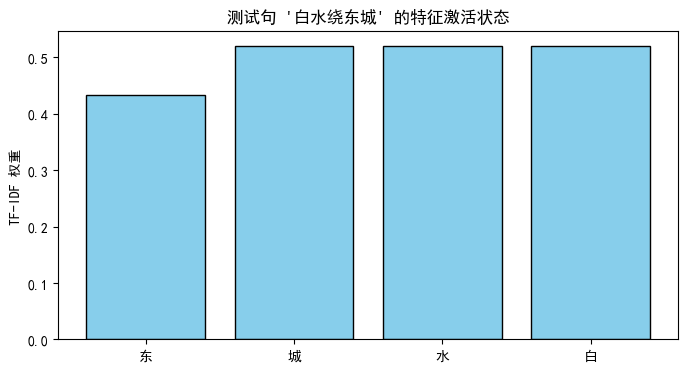

In [3]:
test_sentence = ["白水绕东城"]

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(1, 2))
X_train = vectorizer.fit_transform(df['text'])
y_author = df['author']
y_position = df['position']

X_test = vectorizer.transform(test_sentence)
feature_names = vectorizer.get_feature_names_out()

print(f"通过训练集，模型共学习到了 {len(feature_names)} 个不同的特征维度。\n")

# 剖析目标句子的特征提取情况
test_features = X_test.toarray()[0]
active_indices = np.where(test_features > 0)[0]

print(f"目标测试句: '{test_sentence[0]}'")
print("该句子激活的特征及其 TF-IDF 权重:")
features_dict = {}
for idx in active_indices:
    features_dict[feature_names[idx]] = test_features[idx]
    print(f" - '{feature_names[idx]}': {test_features[idx]:.4f}")

# 绘制特征权重条形图
plt.figure(figsize=(8, 4))
plt.bar(features_dict.keys(), features_dict.values(), color='skyblue', edgecolor='black')
plt.title(f"测试句 '{test_sentence[0]}' 的特征激活状态")
plt.ylabel("TF-IDF 权重")
plt.show()

**结果分析：** 可以看到，“白水绕东城”被切分成了单字（白、水、城）和双字串（白水、水绕等）。由于训练集中恰好出现了“白”字（如“一行白鹭”），“白”字被激活并赋予了权重。那些训练集中从未出现过的字词则权重为 0。

## 3. 特征空间降维与可视化 (PCA)
目前的数据处于数百维的高维空间。我们使用主成分分析（PCA）将其压缩到 2 维平面上，直观观察李白和杜甫诗句的分布格局，以及目标句子落在哪个区域。

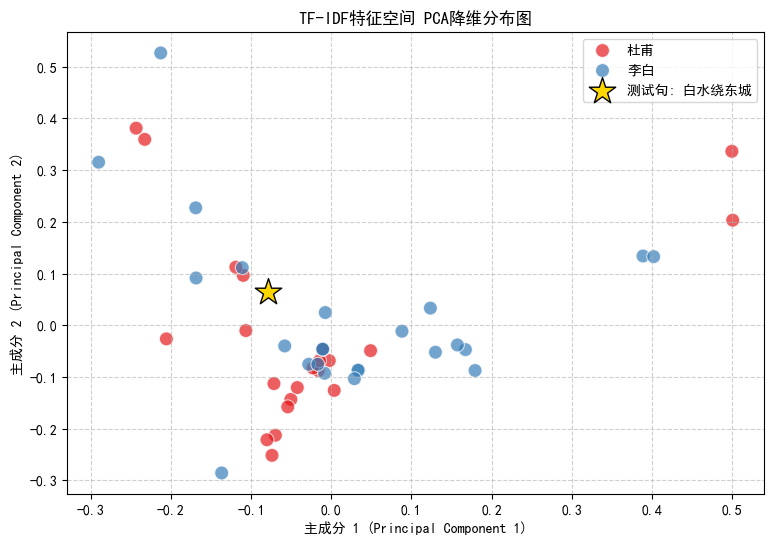

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train.toarray())
X_test_pca = pca.transform(X_test.toarray())

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['author'], palette='Set1', s=100, alpha=0.7)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], color='gold', marker='*', s=400, edgecolor='black', label=f'测试句: {test_sentence[0]}')
plt.title('TF-IDF特征空间 PCA降维分布图')
plt.xlabel('主成分 1 (Principal Component 1)')
plt.ylabel('主成分 2 (Principal Component 2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 4. 统计判别：计算后验概率
基于贝叶斯定理，我们计算出测试句子属于各个类别的概率，概率最大的即为模型的最终判断结果。

=== 最终判决结果 ===
预测作者: 杜甫
预测位置: 第 2 句



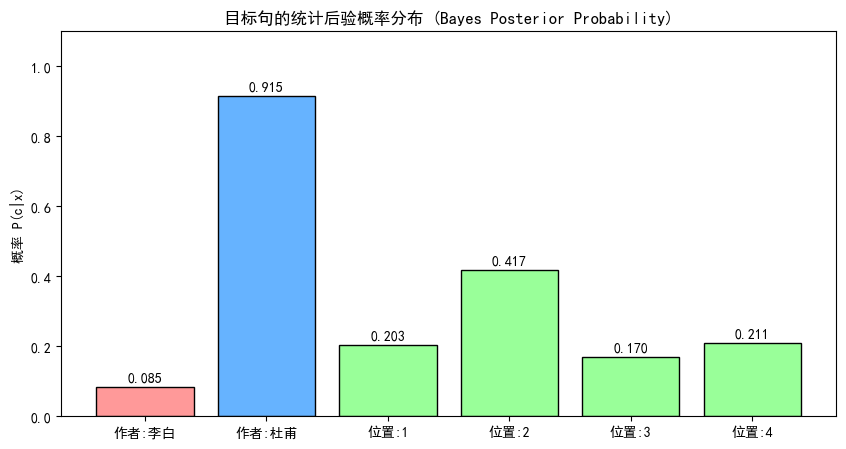

In [5]:
# 任务 1：判别作者
clf_author = MultinomialNB(alpha=0.1)
clf_author.fit(X_train, y_author)
pred_author = clf_author.predict(X_test)[0]
prob_author = clf_author.predict_proba(X_test)[0]
classes_author = clf_author.classes_

# 任务 2：判别句子位置
clf_position = MultinomialNB(alpha=0.1)
clf_position.fit(X_train, y_position)
pred_position = clf_position.predict(X_test)[0]
prob_position = clf_position.predict_proba(X_test)[0]
classes_position = clf_position.classes_

print(f"=== 最终判决结果 ===")
print(f"预测作者: {pred_author}")
print(f"预测位置: 第 {pred_position} 句\n")

# 绘制后验概率分布
plt.figure(figsize=(10, 5))
probs = list(prob_author) + list(prob_position)
labels = [f"作者:{c}" for c in classes_author] + [f"位置:{p}" for p in classes_position]
colors = ['#ff9999', '#66b3ff'] + ['#99ff99']*len(classes_position)

bars = plt.bar(labels, probs, color=colors, edgecolor='black')
plt.title('目标句的统计后验概率分布 (Bayes Posterior Probability)')
plt.ylabel('概率 P(c|x)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom')

plt.ylim(0, 1.1)
plt.show()